# `maws.space` — surface-aware sampler analysis

End-to-end visual inspection of the surface-aware sampling region. Loads
`data/1BRQ.pdb` (RNase A) and walks through:

1. Ligand geometry (atoms, COM offset).
2. Auto-sized envelopes per shape.
3. Surface rejection in action.
4. Per-shape efficiency.
5. Probe / reach sweeps.
6. Failure mode.
7. Old (20 Å cube) vs new behavior.


## 1. Setup + PDB cleaning

Imports, working directory, and a one-shot PDB cleaning step. `resolve_pdb_path`
strips waters / alt-confs / hydrogens for protein inputs so raw RCSB structures
work without manual editing. Switch `INPUT_PDB` to point at any PDB in `data/`.


In [1]:
import logging
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)
from openmm import unit

from maws import space
from maws.complex import Complex
from maws.helpers import center_of_mass, mass_weighted_center, nostrom
from maws.pdb_cleaner import resolve_pdb_path

# Resolve paths relative to repo root (notebook lives at notebooks/maws/).
os.chdir("../..")

np.random.seed(0)  # reproducibility

# To analyse a different ligand, change INPUT_PDB and (if not a protein)
# MOLECULE_TYPE. resolve_pdb_path strips waters/alt-confs/hydrogens for
# proteins so raw RCSB downloads work without manual editing.
INPUT_PDB = "data/1BRQ.pdb"
MOLECULE_TYPE = "protein"  # "protein" | "organic" | "lipid"

PDB_PATH, _original = resolve_pdb_path(
    INPUT_PDB,
    molecule_type=MOLECULE_TYPE,
    clean_pdb=True,
    keep_chains="all",
    remove_h=True,
    drop_hetatm=False,
    logger=logging.getLogger("notebook"),
)
print(f"Using PDB: {PDB_PATH}")

Using PDB: /home/siddharth/work/MAWS_2025/data/1BRQ_cleaned.pdb


## 2. Build the ligand-only `Complex`

Load `data/1BRQ.pdb` and parameterize with `leaprc.protein.ff19SB`.


In [2]:
ligand_only = Complex(
    force_field_aptamer="leaprc.RNA.OL3",
    force_field_ligand="leaprc.protein.ff19SB",
)
ligand_only.add_chain_from_pdb(
    pdb_path=PDB_PATH,
    force_field_aptamer="leaprc.RNA.OL3",
    force_field_ligand="leaprc.protein.ff19SB",
    parameterized=True,
)
ligand_only.build()

n_atoms = sum(1 for _ in ligand_only.topology.atoms())
print(f"Atoms in ligand: {n_atoms}")

-I: Adding /home/siddharth/miniforge3/envs/maws/dat/leap/prep to search path.
-I: Adding /home/siddharth/miniforge3/envs/maws/dat/leap/lib to search path.
-I: Adding /home/siddharth/miniforge3/envs/maws/dat/leap/parm to search path.
-I: Adding /home/siddharth/miniforge3/envs/maws/dat/leap/cmd to search path.
-f: Source leap.in.

Welcome to LEaP!
(no leaprc in search path)
Sourcing: ./leap.in
----- Source: /home/siddharth/miniforge3/envs/maws/dat/leap/cmd/leaprc.RNA.OL3
----- Source of /home/siddharth/miniforge3/envs/maws/dat/leap/cmd/leaprc.RNA.OL3 done
Log file: ./leap.log
Loading parameters: /home/siddharth/miniforge3/envs/maws/dat/leap/parm/parm10.dat
Reading title:
PARM99 + frcmod.ff99SB + frcmod.parmbsc0 + OL3 for RNA
Loading library: /home/siddharth/miniforge3/envs/maws/dat/leap/lib/RNA.lib
----- Source: /home/siddharth/miniforge3/envs/maws/dat/leap/cmd/leaprc.protein.ff19SB
----- Source of /home/siddharth/miniforge3/envs/maws/dat/leap/cmd/leaprc.protein.ff19SB done
Log file: ./l

Atoms in ligand: 2760


/home/siddharth/miniforge3/envs/maws/lib/python3.11/site-packages/openmm/app/internal/amber_file_parser.py:1165: UserWarning: Non-optimal GB parameters detected for GB model OBC1
  warnings.warn(
/home/siddharth/work/MAWS_2025/maws/complex.py:398: RuntimeWarning: Platform 'CUDA' unavailable: There is no registered Platform called "CUDA"
  self.simulation = self._create_simulation()
/home/siddharth/work/MAWS_2025/maws/complex.py:398: RuntimeWarning: Platform 'OpenCL' unavailable: There is no registered Platform called "OpenCL"
  self.simulation = self._create_simulation()


## 3. Geometric inspection

Plot atoms in 3D, colored by element. Show centroid vs true mass-weighted COM.


In [3]:
positions = np.asarray(nostrom(ligand_only.positions), dtype=float)
masses = np.array(
    [a.element.mass.value_in_unit(unit.dalton) for a in ligand_only.topology.atoms()]
)
elements = [a.element.symbol for a in ligand_only.topology.atoms()]

centroid = center_of_mass(positions)
com_true = mass_weighted_center(positions, masses)
print(f"Centroid:  {centroid}")
print(f"True COM:  {com_true}")
print(f"Offset:    {np.linalg.norm(centroid - com_true):.3f} \u00c5")

dists = np.linalg.norm(positions - com_true, axis=1)
print(
    f"R_min = {dists.min():.2f} \u00c5, R_max = {dists.max():.2f} \u00c5, "
    f"anisotropy = {dists.max() / max(dists.min(), 1e-9):.2f}"
)

Centroid:  [ 20.03377357  46.49850452 -35.82121213]
True COM:  [ 20.10402221  46.59802721 -35.79509779]
Offset:    0.125 Å
R_min = 1.55 Å, R_max = 28.97 Å, anisotropy = 18.63


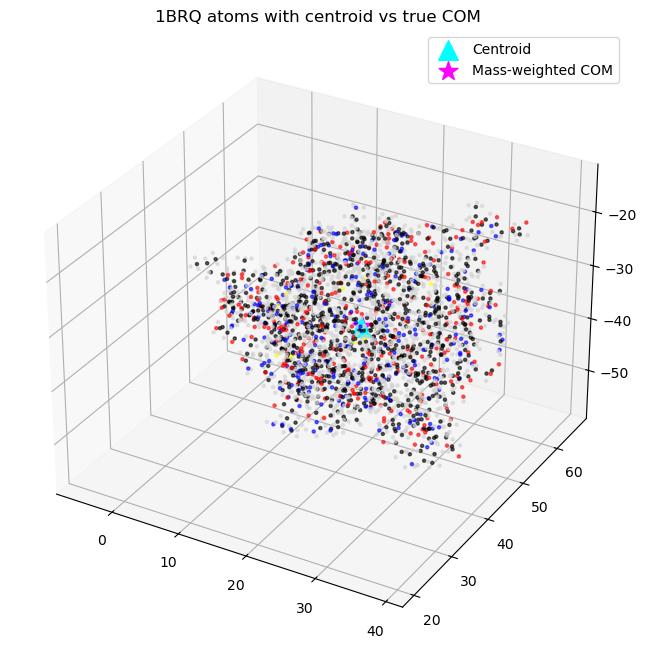

In [4]:
color_map = {
    "H": "lightgray",
    "C": "black",
    "N": "blue",
    "O": "red",
    "S": "yellow",
    "P": "orange",
}
colors = [color_map.get(e, "magenta") for e in elements]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], c=colors, s=5, alpha=0.6)
ax.scatter(*centroid, color="cyan", s=200, marker="^", label="Centroid")
ax.scatter(*com_true, color="magenta", s=200, marker="*", label="Mass-weighted COM")
ax.set_title("1BRQ atoms with centroid vs true COM")
ax.legend()
plt.show()

## 4. Shape primer — what each envelope looks like

Before we fit envelopes to a real protein in the next section, here are
the three shapes drawn in 2D with a stylized blobby ligand. These plots
are pure geometry (no PDB data) so they render instantly.

For each shape the green outline is the envelope MAWS samples from; the
gray blob is the ligand; the magenta star is the mass-weighted COM that
`compute_envelope_dims` centers everything on.


In [ ]:
import matplotlib.patches as mpatches

# Stylized blob: irregular octagon to suggest a non-spherical ligand.
blob_xy = np.array(
    [
        (-3.5, -1.0),
        (-2.0, -2.5),
        (0.5, -3.0),
        (3.0, -2.0),
        (4.0, 0.0),
        (3.0, 2.0),
        (0.5, 2.5),
        (-2.5, 1.5),
    ]
)
blob_r_max = max((x * x + y * y) ** 0.5 for x, y in blob_xy)
blob_r_min = min((x * x + y * y) ** 0.5 for x, y in blob_xy)
reach = 2.0  # smaller than 10 Å for a clearer figure

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


def draw_blob(ax):
    ax.add_patch(
        mpatches.Polygon(
            blob_xy, closed=True, facecolor="lightgray", edgecolor="dimgray"
        )
    )
    ax.plot(0, 0, marker="*", color="magenta", markersize=15, zorder=3, label="COM")
    # R_max guide
    ax.plot([0, blob_r_max], [0, 0], color="black", lw=0.8, ls=":")
    ax.text(blob_r_max / 2, 0.3, "R_max", ha="center", fontsize=9)


# --- Cube ---
ax = axes[0]
w = 2 * (blob_r_max + reach)
ax.add_patch(
    mpatches.Rectangle((-w / 2, -w / 2), w, w, fill=False, edgecolor="green", lw=2)
)
draw_blob(ax)
ax.set_title(f"Cube  — width = 2·(R_max + reach) = {w:.1f}", fontsize=11)

# --- Sphere ---
ax = axes[1]
r = blob_r_max + reach
ax.add_patch(mpatches.Circle((0, 0), r, fill=False, edgecolor="green", lw=2))
draw_blob(ax)
ax.set_title(f"Sphere — radius = R_max + reach = {r:.1f}", fontsize=11)

# --- Shell ---
ax = axes[2]
r_outer = blob_r_max + reach
buffer = 1.0  # smaller than the real 5 Å for visual clarity
r_inner = max(0.0, blob_r_min - buffer)
ax.add_patch(
    mpatches.Circle((0, 0), r_outer, fill=False, edgecolor="green", lw=2, label="outer")
)
ax.add_patch(
    mpatches.Circle(
        (0, 0), r_inner, fill=False, edgecolor="orange", lw=2, ls="--", label="inner"
    )
)
draw_blob(ax)
ax.set_title(
    f"Shell  — inner = R_min − buffer = {r_inner:.1f},\n"
    f"          outer = R_max + reach = {r_outer:.1f}",
    fontsize=11,
)

for ax in axes:
    ax.set_xlim(-8, 8)
    ax.set_ylim(-8, 8)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="lightgray", lw=0.5)
    ax.axvline(0, color="lightgray", lw=0.5)

plt.tight_layout()
plt.show()

### Why does Shell have an inner radius — doesn't it miss surface points?

Common worry: *"if the inner radius is `R_min − 5`, won't we miss surface
samples close to the protein?"* — no, because of how `R_min` is defined.

`R_min` is the distance from the COM to the **closest** atom. For most
proteins the closest atom is on or near the surface along the protein's
**thinnest** direction. So `R_min` already corresponds to "surface
distance, short axis." Anything closer to COM than `R_min` is — by
definition — inside the convex shell of atoms, i.e. inside the bulk
regardless of which direction you look. The `−5 Å` buffer just gives a
small safety margin so we don't accidentally clip the short-axis surface.

Below: an elongated ligand (long axis horizontal). The shell band (light
green) covers the surface along *every* direction. Inside the inner
circle (gray) is guaranteed-bulk territory we skip on purpose.


In [ ]:
from matplotlib.patches import Circle, Ellipse

# Elongated ligand: long axis along x.
R_long = 6.0  # tip-of-blob distance from COM (R_max)
R_short = 2.0  # short-axis blob distance from COM (R_min)
buffer = 1.0  # smaller than real 5 Å for visual clarity
reach = 2.0

inner = max(0.0, R_short - buffer)
outer = R_long + reach

fig, ax = plt.subplots(figsize=(10, 6))

# Outside (not sampled) — light blue background
ax.add_patch(Circle((0, 0), 12, facecolor="#e8f4ff", edgecolor="none", zorder=0))
# Shell band (sampled, SAS decides) — light green
ax.add_patch(
    Circle((0, 0), outer, facecolor="#d8f5d8", edgecolor="green", lw=2, zorder=1)
)
# Inner zone (guaranteed bulk, not sampled) — light gray
ax.add_patch(
    Circle(
        (0, 0), inner, facecolor="#cccccc", edgecolor="orange", lw=2, ls="--", zorder=2
    )
)
# Ligand blob: elongated ellipse along x
ax.add_patch(
    Ellipse(
        (0, 0),
        2 * R_long,
        2 * R_short,
        facecolor="dimgray",
        edgecolor="black",
        lw=1.5,
        alpha=0.85,
        zorder=3,
    )
)
# COM
ax.plot(0, 0, marker="*", color="magenta", markersize=18, zorder=4)

# Direction arrows showing where the surface is
# Short-axis surface point (top)
ax.plot(0, R_short, marker="o", color="red", markersize=8, zorder=5)
ax.annotate(
    "surface point on short axis\n(distance = R_min)",
    xy=(0, R_short),
    xytext=(3, 4.5),
    arrowprops={"arrowstyle": "->", "color": "red", "lw": 1},
    fontsize=9,
    color="red",
)
# Long-axis surface point (right)
ax.plot(R_long, 0, marker="o", color="red", markersize=8, zorder=5)
ax.annotate(
    "surface point on long axis\n(distance = R_max)",
    xy=(R_long, 0),
    xytext=(R_long + 1.5, -3),
    arrowprops={"arrowstyle": "->", "color": "red", "lw": 1},
    fontsize=9,
    color="red",
)

# Annotations for the three regions
ax.text(
    0,
    -1.2,
    "guaranteed bulk\n(< R_min − buffer)\n← skipped →",
    ha="center",
    va="top",
    fontsize=9,
    color="black",
    bbox={"facecolor": "white", "edgecolor": "orange", "boxstyle": "round"},
)
ax.text(
    0,
    outer + 0.3,
    "shell band [inner, outer] — sampled; SAS rejects bulk-side, accepts surface-side",
    ha="center",
    fontsize=9,
    color="green",
    bbox={"facecolor": "white", "edgecolor": "green", "boxstyle": "round"},
)
ax.text(
    0,
    11.2,
    "outside the envelope (> R_max + reach) — not sampled",
    ha="center",
    fontsize=9,
    color="steelblue",
    bbox={"facecolor": "white", "edgecolor": "steelblue", "boxstyle": "round"},
)

ax.set_xlim(-12, 12)
ax.set_ylim(-8, 12)
ax.set_aspect("equal")
ax.set_title(
    "Why Shell with `inner = R_min − buffer` doesn't miss surface points", fontsize=11
)
ax.grid(True, alpha=0.3)
ax.axhline(0, color="lightgray", lw=0.5)
ax.axvline(0, color="lightgray", lw=0.5)
plt.tight_layout()
plt.show()

## 5. Auto-sized envelopes per shape

`compute_envelope_dims` for each shape with reach=10 Å; envelope outline overlaid.


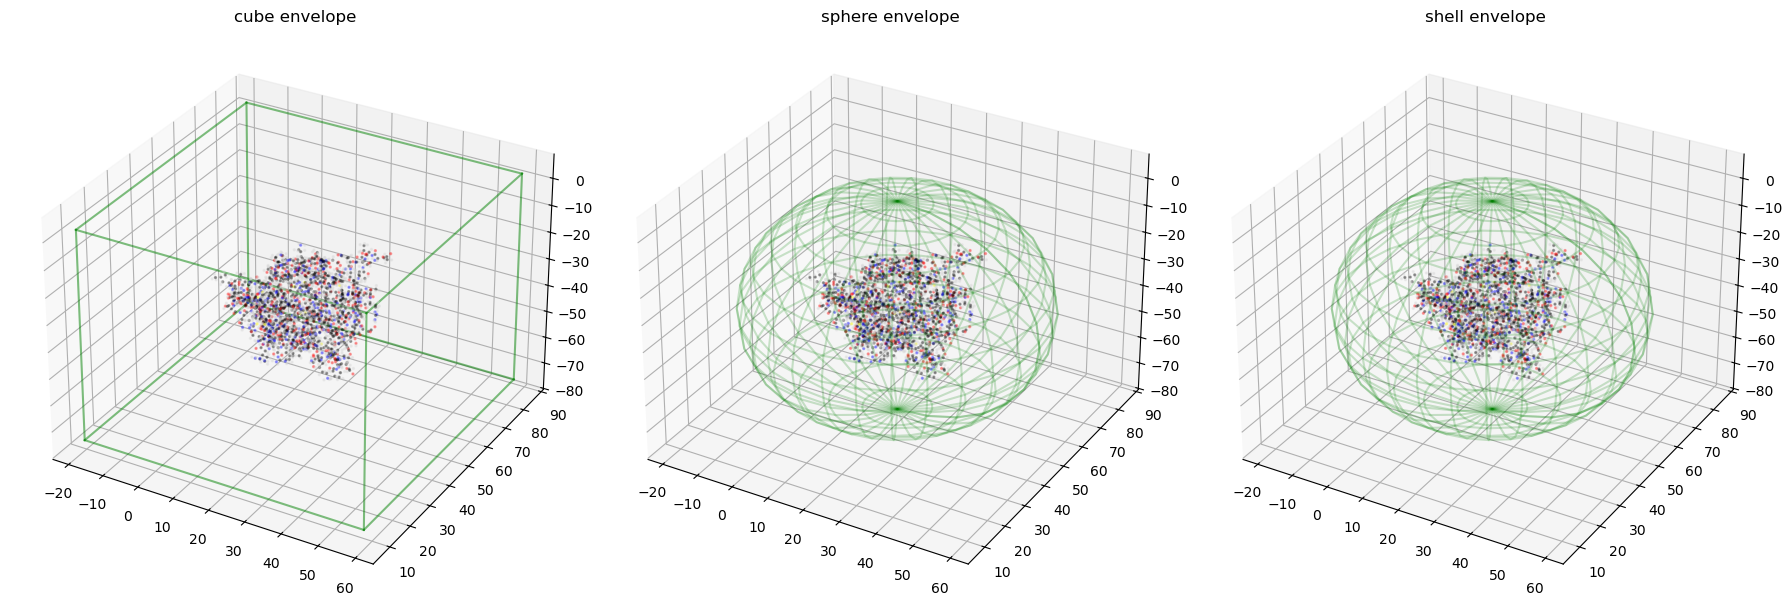

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={"projection": "3d"})

for ax, shape in zip(axes, ["cube", "sphere", "shell"], strict=False):
    dims = space.compute_envelope_dims(ligand_only, shape, reach=10.0)
    ax.scatter(
        positions[:, 0], positions[:, 1], positions[:, 2], c=colors, s=2, alpha=0.3
    )
    ax.set_title(f"{shape} envelope")
    if shape == "cube":
        c = dims["centre"]
        w = dims["width"] / 2
        # draw the 12 cube edges
        corners = [
            (c[0] + sx * w, c[1] + sy * w, c[2] + sz * w)
            for sx in (-1, 1)
            for sy in (-1, 1)
            for sz in (-1, 1)
        ]
        edges = [
            (0, 1),
            (1, 3),
            (3, 2),
            (2, 0),
            (4, 5),
            (5, 7),
            (7, 6),
            (6, 4),
            (0, 4),
            (1, 5),
            (2, 6),
            (3, 7),
        ]
        for a, b in edges:
            xa, ya, za = corners[a]
            xb, yb, zb = corners[b]
            ax.plot([xa, xb], [ya, yb], [za, zb], color="green", alpha=0.5)
    elif shape == "sphere":
        u, v = np.mgrid[0 : 2 * np.pi : 30j, 0 : np.pi : 15j]
        r = dims["radius"]
        c = dims["centre"]
        x = c[0] + r * np.cos(u) * np.sin(v)
        y = c[1] + r * np.sin(u) * np.sin(v)
        z = c[2] + r * np.cos(v)
        ax.plot_wireframe(x, y, z, color="green", alpha=0.2)
    else:  # shell
        c = dims["centre"]
        for r, color in [(dims["inner"], "orange"), (dims["outer"], "green")]:
            if r <= 0:
                continue
            u, v = np.mgrid[0 : 2 * np.pi : 30j, 0 : np.pi : 15j]
            x = c[0] + r * np.cos(u) * np.sin(v)
            y = c[1] + r * np.sin(u) * np.sin(v)
            z = c[2] + r * np.cos(v)
            ax.plot_wireframe(x, y, z, color=color, alpha=0.2)

plt.tight_layout()
plt.show()

## 6. Surface rejection in action

Build an `Excluder` (probe=1.4 Å) and draw 2000 raw envelope samples per shape.
Color accepted (green) vs rejected (red).


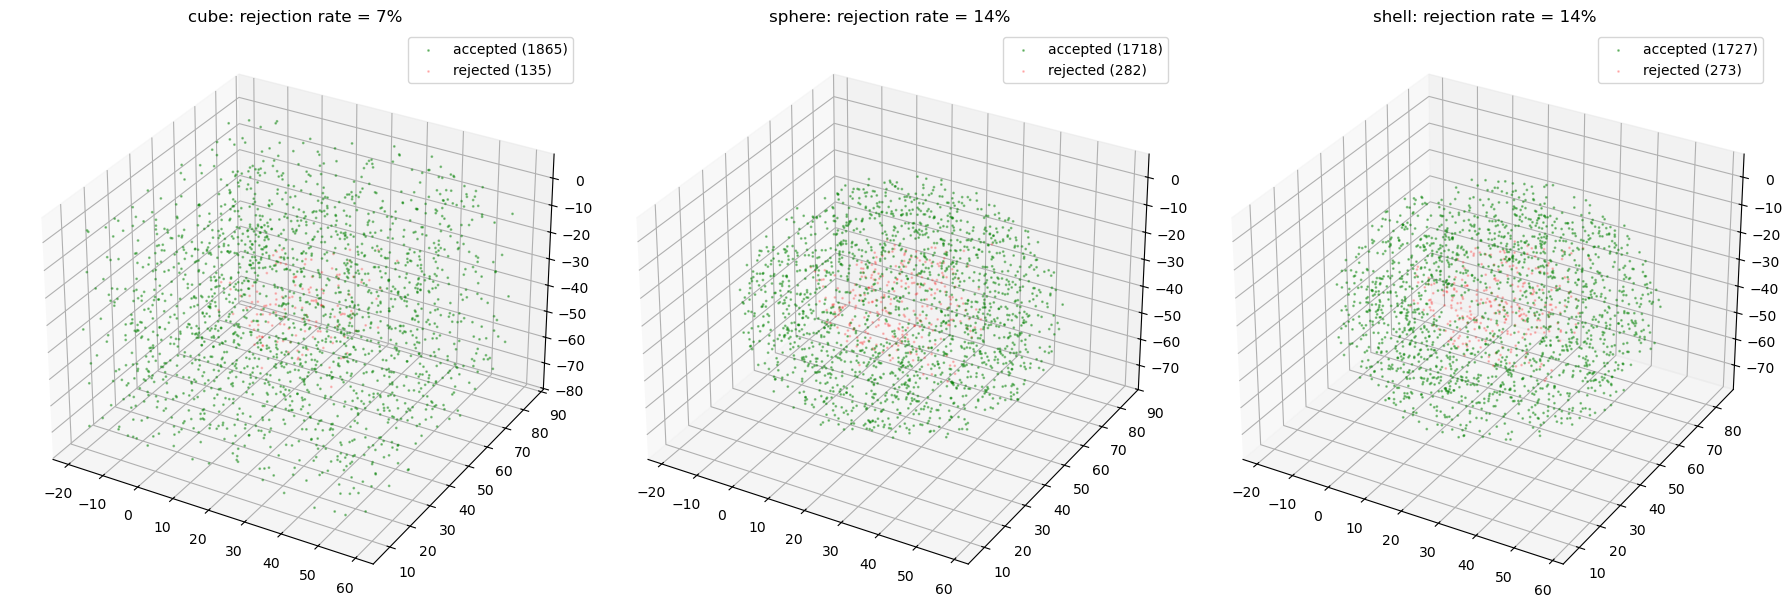

In [6]:
excluder = space.Excluder(ligand_only, probe=1.4)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={"projection": "3d"})
for ax, shape in zip(axes, ["cube", "sphere", "shell"], strict=False):
    dims = space.compute_envelope_dims(ligand_only, shape, reach=10.0)
    cls = {"cube": space.Cube, "sphere": space.Sphere, "shell": space.Shell}[shape]
    envelope = cls(**dims)
    accepted, rejected = [], []
    for _ in range(2000):
        s = envelope.generator().position
        (accepted if excluder.is_clear(s) else rejected).append(s)
    accepted = np.array(accepted) if accepted else np.empty((0, 3))
    rejected = np.array(rejected) if rejected else np.empty((0, 3))
    if len(accepted):
        ax.scatter(
            *accepted.T,
            color="green",
            s=1,
            alpha=0.4,
            label=f"accepted ({len(accepted)})",
        )
    if len(rejected):
        ax.scatter(
            *rejected.T,
            color="red",
            s=1,
            alpha=0.2,
            label=f"rejected ({len(rejected)})",
        )
    ax.set_title(f"{shape}: rejection rate = {len(rejected) / 2000:.0%}")
    ax.legend()
plt.tight_layout()
plt.show()

## 7. Per-shape sampling efficiency

Bar chart: rejection rate by shape (lower = better) and µs per accepted sample.


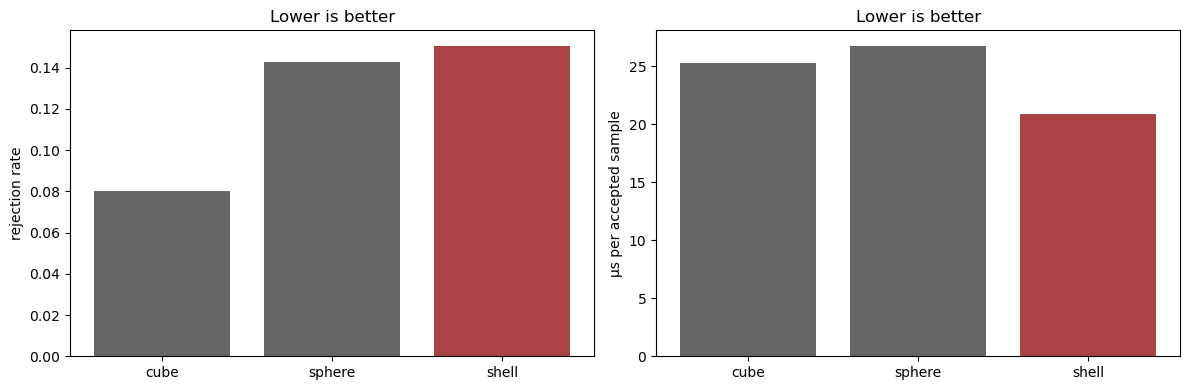

In [7]:
results = {}
for shape in ("cube", "sphere", "shell"):
    sampler = space.make_sampler(shape, ligand_only)
    t0 = time.perf_counter()
    n = 1000
    for _ in range(n):
        sampler.generator()
    dt_us = (time.perf_counter() - t0) / n * 1e6
    dims = space.compute_envelope_dims(ligand_only, shape, 10.0)
    cls = {"cube": space.Cube, "sphere": space.Sphere, "shell": space.Shell}[shape]
    env = cls(**dims)
    rej = (
        sum(1 for _ in range(2000) if not excluder.is_clear(env.generator().position))
        / 2000
    )
    results[shape] = (rej, dt_us)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(
    results.keys(), [r[0] for r in results.values()], color=["#666", "#666", "#a44"]
)
ax1.set_ylabel("rejection rate")
ax1.set_title("Lower is better")
ax2.bar(
    results.keys(), [r[1] for r in results.values()], color=["#666", "#666", "#a44"]
)
ax2.set_ylabel("\u00b5s per accepted sample")
ax2.set_title("Lower is better")
plt.tight_layout()
plt.show()

## 8. Probe + reach sweeps

How does the accessible region change with `probe` ∈ {0.5, 1.4, 2.5} and
`reach` ∈ {5, 10, 20}? Top row: vary probe; bottom row: vary reach.


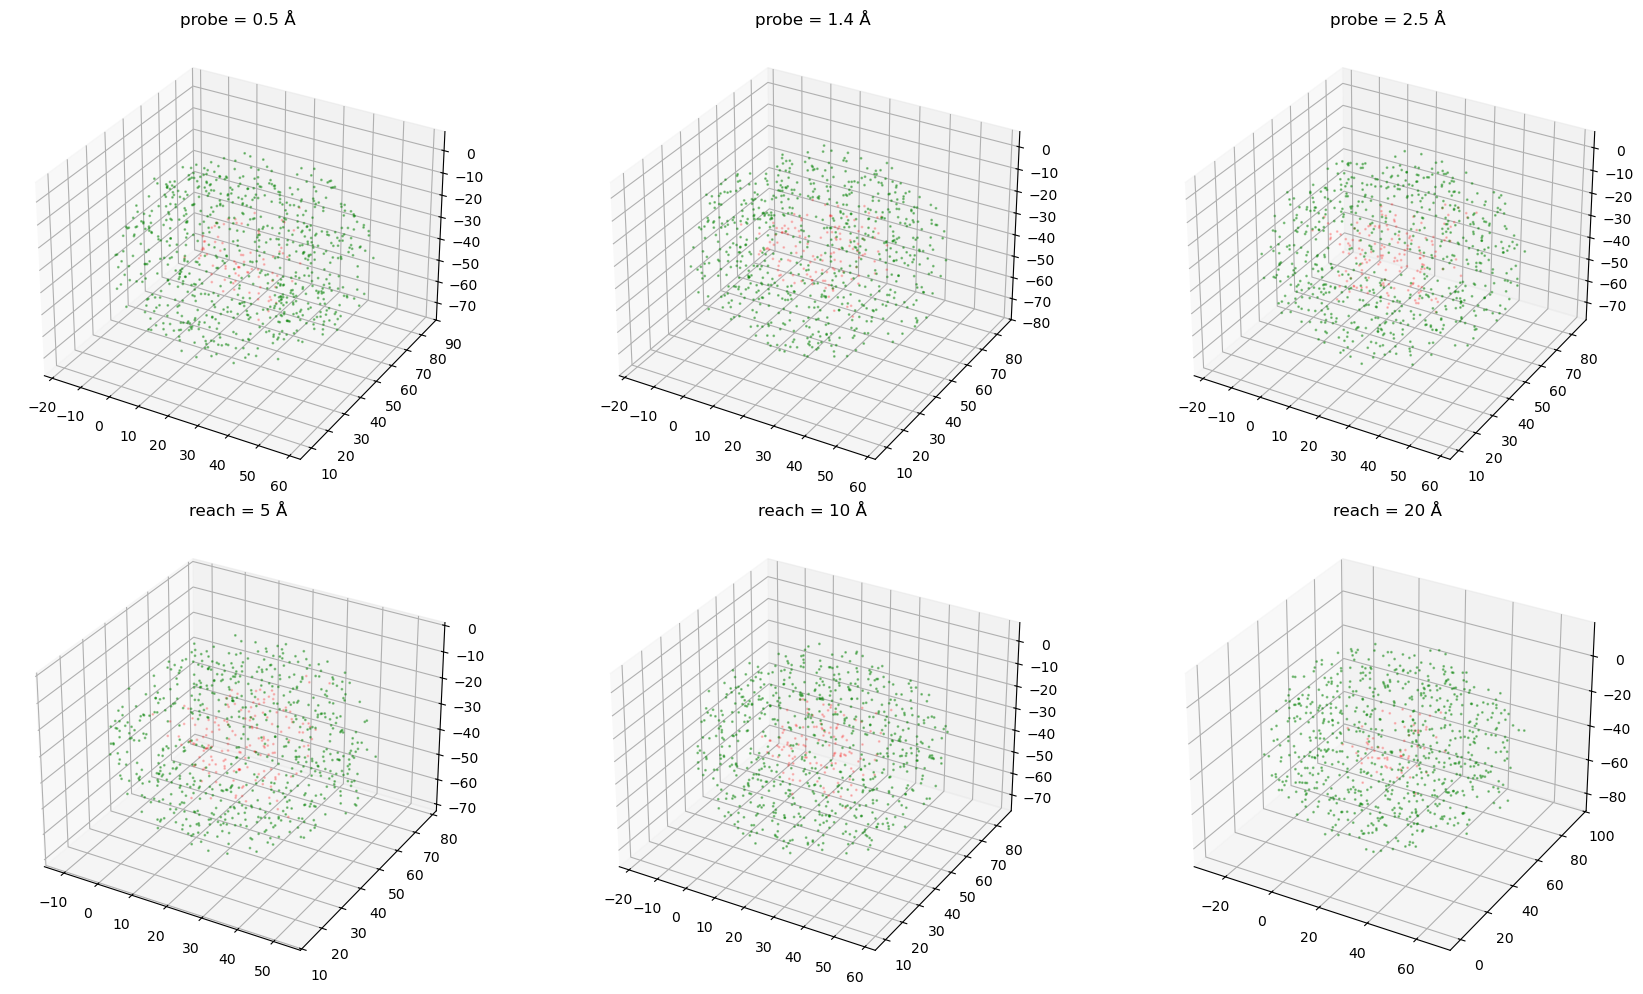

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={"projection": "3d"})

for j, probe in enumerate((0.5, 1.4, 2.5)):
    ex = space.Excluder(ligand_only, probe=probe)
    sphere = space.Sphere(**space.compute_envelope_dims(ligand_only, "sphere", 10.0))
    pts = np.array([sphere.generator().position for _ in range(800)])
    clear = np.array([ex.is_clear(p) for p in pts])
    ax = axes[0, j]
    ax.scatter(*pts[clear].T, color="green", s=1, alpha=0.4)
    ax.scatter(*pts[~clear].T, color="red", s=1, alpha=0.2)
    ax.set_title(f"probe = {probe} \u00c5")

for j, reach in enumerate((5, 10, 20)):
    ex = space.Excluder(ligand_only, probe=1.4)
    sphere = space.Sphere(**space.compute_envelope_dims(ligand_only, "sphere", reach))
    pts = np.array([sphere.generator().position for _ in range(800)])
    clear = np.array([ex.is_clear(p) for p in pts])
    ax = axes[1, j]
    ax.scatter(*pts[clear].T, color="green", s=1, alpha=0.4)
    ax.scatter(*pts[~clear].T, color="red", s=1, alpha=0.2)
    ax.set_title(f"reach = {reach} \u00c5")

plt.tight_layout()
plt.show()

## 9. Failure mode: fully buried envelope

If the envelope is too small / too deep, no clear point exists. The sampler
should raise `SamplingError` rather than infinite-loop.


In [9]:
buried = space.SurfaceSampler(
    envelope=space.Cube(width=0.1, centre=com_true),
    excluder=excluder,
    max_rejections=20,
)
try:
    buried.generator()
except space.SamplingError as exc:
    print("Caught SamplingError as expected:")
    print(exc)

Caught SamplingError as expected:
Could not draw a clear point in 20 attempts. Envelope may be fully buried - increase --reach, decrease --probe, or check ligand size.


## 10. Old (20 Å cube) vs new behavior

Plot the previous 20 Å cube around the protein next to the new auto-sized
shell + surface rejection. The old default mostly samples the protein
interior; the new default hugs the surface.


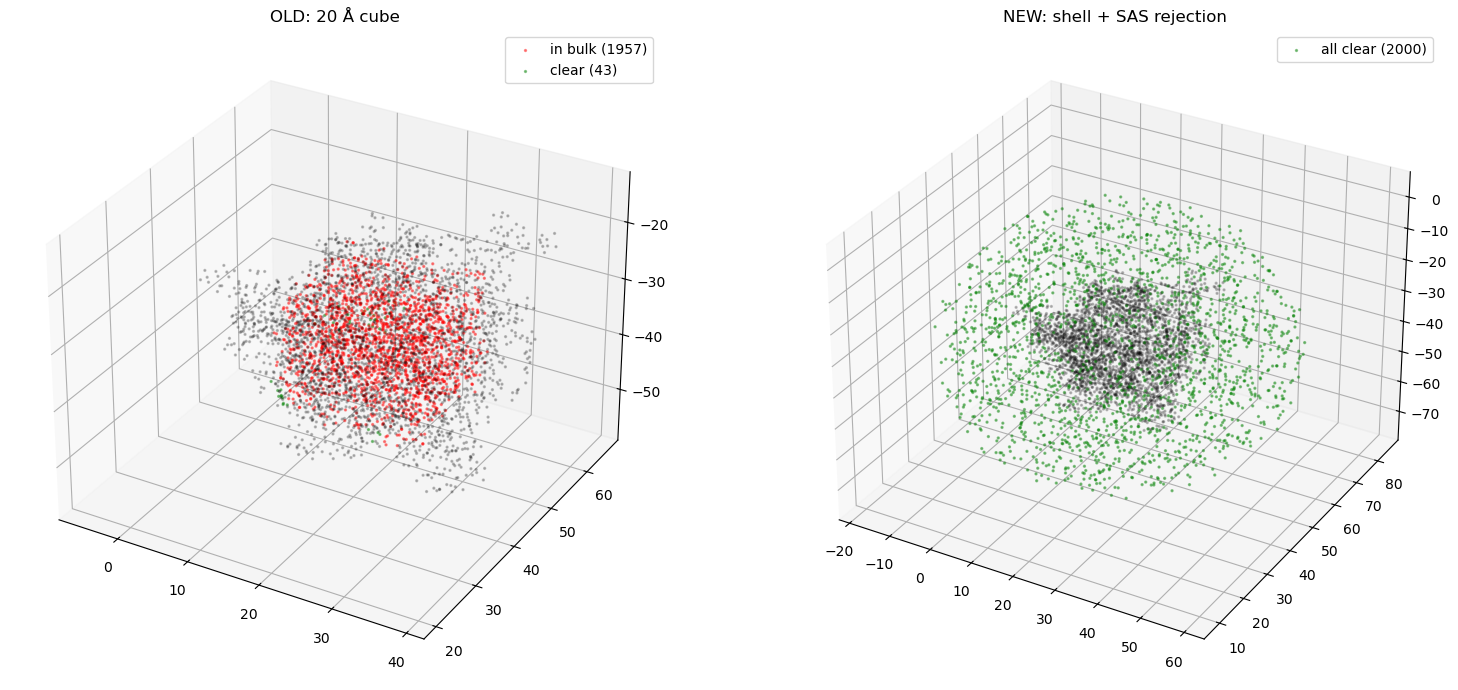

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw={"projection": "3d"})

# Old: 20 Å cube, no rejection
old_cube = space.Cube(width=20.0, centre=com_true)
pts_old = np.array([old_cube.generator().position for _ in range(2000)])
in_protein = np.array([not excluder.is_clear(p) for p in pts_old])
axes[0].scatter(
    positions[:, 0], positions[:, 1], positions[:, 2], color="black", s=2, alpha=0.2
)
axes[0].scatter(
    *pts_old[in_protein].T,
    color="red",
    s=2,
    alpha=0.4,
    label=f"in bulk ({in_protein.sum()})",
)
axes[0].scatter(
    *pts_old[~in_protein].T,
    color="green",
    s=2,
    alpha=0.4,
    label=f"clear ({(~in_protein).sum()})",
)
axes[0].set_title("OLD: 20 \u00c5 cube")
axes[0].legend()

# New: auto-sized shell + rejection
new_sampler = space.make_sampler("shell", ligand_only)
pts_new = np.array([new_sampler.generator().position for _ in range(2000)])
axes[1].scatter(
    positions[:, 0], positions[:, 1], positions[:, 2], color="black", s=2, alpha=0.2
)
axes[1].scatter(
    *pts_new.T, color="green", s=2, alpha=0.4, label=f"all clear ({len(pts_new)})"
)
axes[1].set_title("NEW: shell + SAS rejection")
axes[1].legend()

plt.tight_layout()
plt.show()